# Shape Analysis

Phân tích độ lệch (Skewness) và độ nhọn (Kurtosis) của phân phối dữ liệu.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Load cleaned data
df = pd.read_csv('../data/youtube_clean.csv')

numerical_cols = ['duration', 'bitrate', 'bitrate(video)', 'height', 'width',
                  'frame rate', 'frame rate(est.)', 'views', 'likes', 'comments']

print(f"Dataset shape: {df.shape}")
print(f"Analyzing {len(numerical_cols)} numerical variables")

Dataset shape: (17586, 15)
Analyzing 10 numerical variables


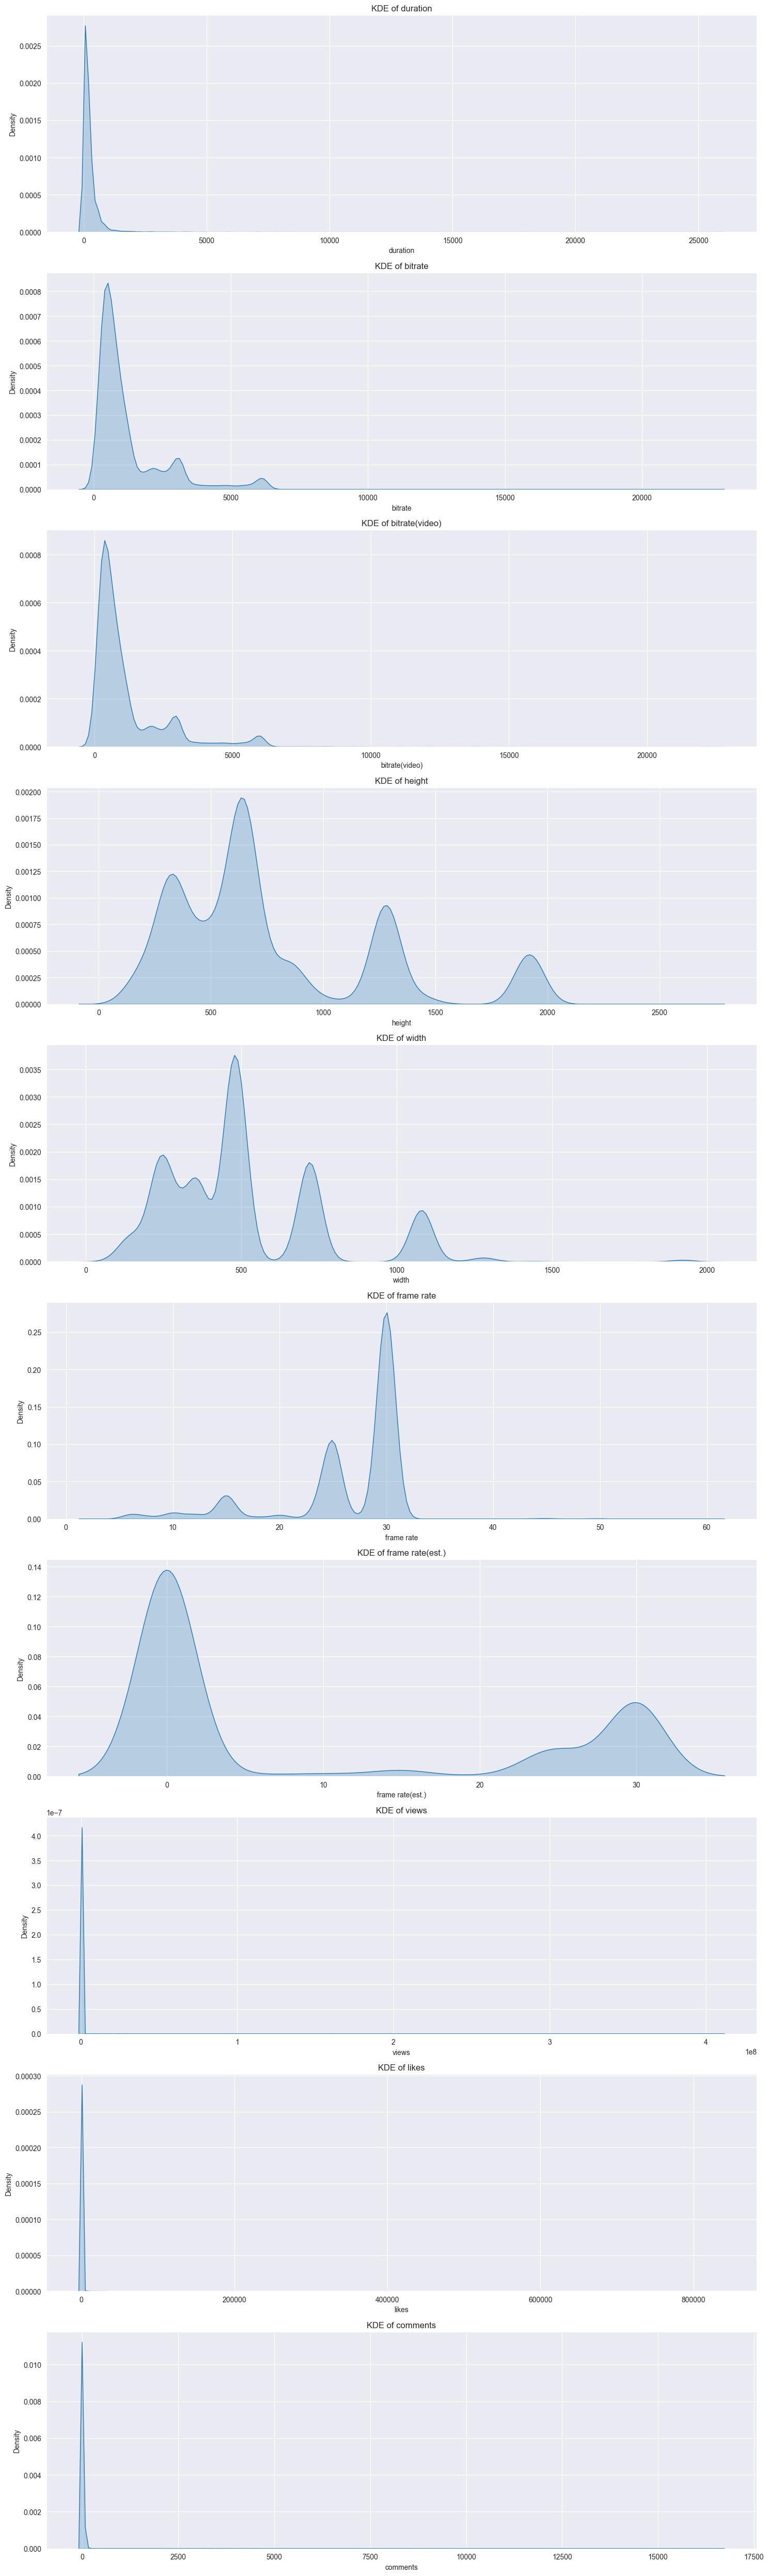

In [5]:
plt.figure(figsize=(15, 5 * len(numerical_cols)))

for i, column in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols), 1, i)
    sns.kdeplot(data=df, x=column, fill=True)
    plt.title(f'KDE of {column}')
    plt.xlabel(column)

plt.tight_layout()
plt.show()

* **Lệch phải**: đặc điểm phổ biến của dữ liệu phân phối tự nhiên (như lượt xem, thu nhập, giá cả) khi có nhiều giá trị nhỏ và ít giá trị cực lớn. Điều này cho thấy dữ liệu gốc có thể cần được biến đổi (ví dụ: dùng phép biến đổi logarit) trước khi áp dụng các mô hình thống kê giả định phân phối chuẩn.
* **Leptokurtic (Độ nhọn cao)**: Hầu hết các biến có độ nhọn cao, đặc biệt là các biến về tương tác người dùng (views, likes, comments). Điều này chỉ ra rằng dữ liệu có mật độ tập trung rất cao xung quanh giá trị trung bình/mode (đỉnh nhọn) và đồng thời có nhiều giá trị ngoại lai (đuôi dày).

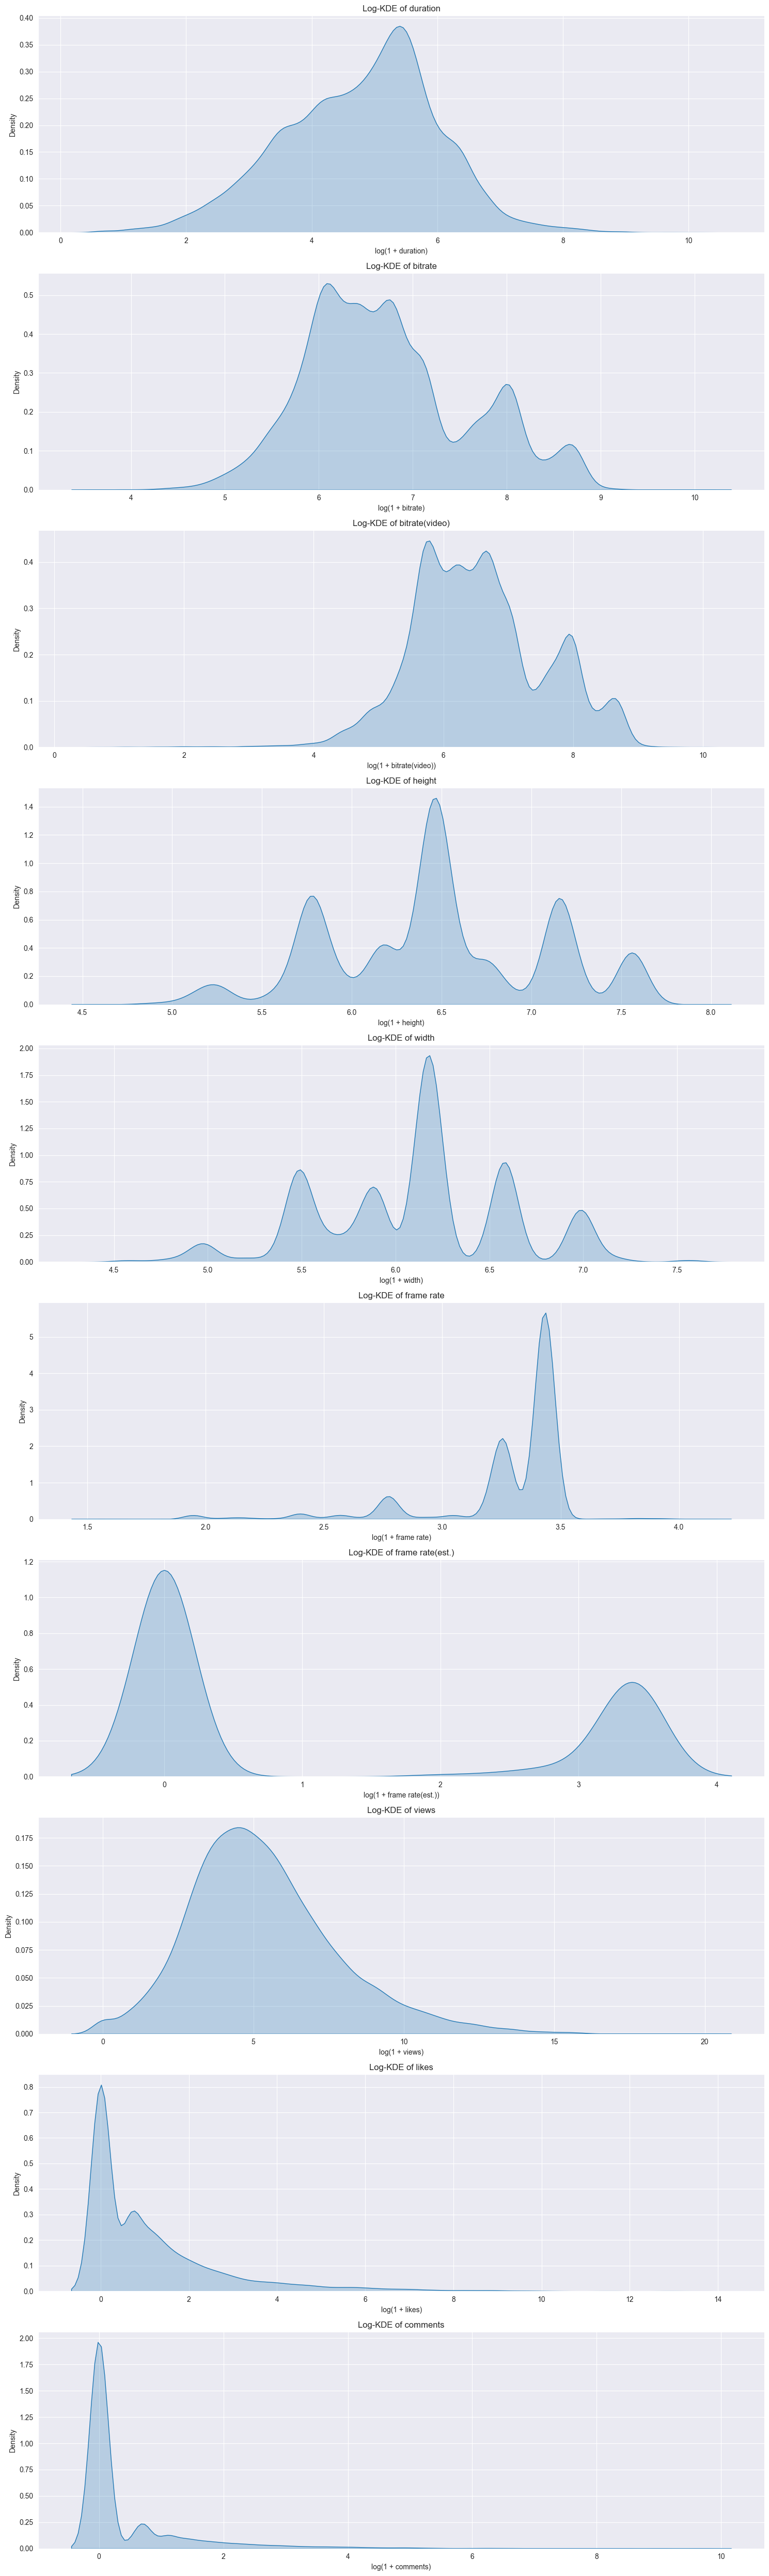

In [6]:
plt.figure(figsize=(15, 5 * len(numerical_cols)))

for i, column in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols), 1, i)
    sns.kdeplot(np.log1p(df[column]), fill=True)
    plt.title(f'Log-KDE of {column}')
    plt.xlabel(f'log(1 + {column})')

plt.tight_layout()
plt.show()

* Các biến này trước đây lệch dương cực mạnh và rất nhọn (Leptokurtic). Sau khi log, phân phối đã trở nên gần đối xứng (nearly symmetric) và hình chuông hơn.
* Độ lệch dương đã giảm đáng kể. Phân phối đã trở nên rộng hơn và ít nhọn hơn.
* Đối với các biến về phân loại/tiêu chuẩn kỹ thuật (height, width), bản chất đa mode của dữ liệu vẫn cần được xử lý riêng (ví dụ: biến đổi thành biến phân loại hoặc phân tích theo từng nhóm mode).

In [3]:
# Phân tích hình dạng phân phối (Shape Analysis)

shape_analysis = pd.DataFrame({
    'Variable': numerical_cols,
    'Skewness': [df[col].skew() for col in numerical_cols],
    'Kurtosis': [df[col].kurtosis() for col in numerical_cols]
})

# Thêm cột phân loại
def classify_skewness(skew):
    if skew > 1:
        return 'Highly Right Skewed'
    elif skew > 0.5:
        return 'Moderately Right Skewed'
    elif skew > -0.5:
        return 'Approximately Symmetric'
    elif skew > -1:
        return 'Moderately Left Skewed'
    else:
        return 'Highly Left Skewed'

def classify_kurtosis(kurt):
    if kurt > 3:
        return 'Leptokurtic (Heavy Tails)'
    elif kurt < -3:
        return 'Platykurtic (Light Tails)'
    else:
        return 'Mesokurtic (Normal)'

shape_analysis['Skewness Type'] = shape_analysis['Skewness'].apply(classify_skewness)
shape_analysis['Kurtosis Type'] = shape_analysis['Kurtosis'].apply(classify_kurtosis)

shape_analysis.round(2)

,Variable,Skewness,Kurtosis,Skewness Type,Kurtosis Type
0,duration,16.99,603.88,Highly Right Skewed,Leptokurtic (Heavy Tails)
1,bitrate,2.41,8.76,Highly Right Skewed,Leptokurtic (Heavy Tails)
2,bitrate(video),2.46,9.22,Highly Right Skewed,Leptokurtic (Heavy Tails)
3,height,1.12,0.47,Highly Right Skewed,Mesokurtic (Normal)
4,width,1.30,2.31,Highly Right Skewed,Mesokurtic (Normal)
5,frame rate,-1.36,2.87,Highly Left Skewed,Mesokurtic (Normal)
6,frame rate(est.),0.75,-1.36,Moderately Right Skewed,Mesokurtic (Normal)
7,views,97.61,10653.82,Highly Right Skewed,Leptokurtic (Heavy Tails)
8,likes,75.60,6439.71,Highly Right Skewed,Leptokurtic (Heavy Tails)
9,comments,49.28,3119.21,Highly Right Skewed,Leptokurtic (Heavy Tails)


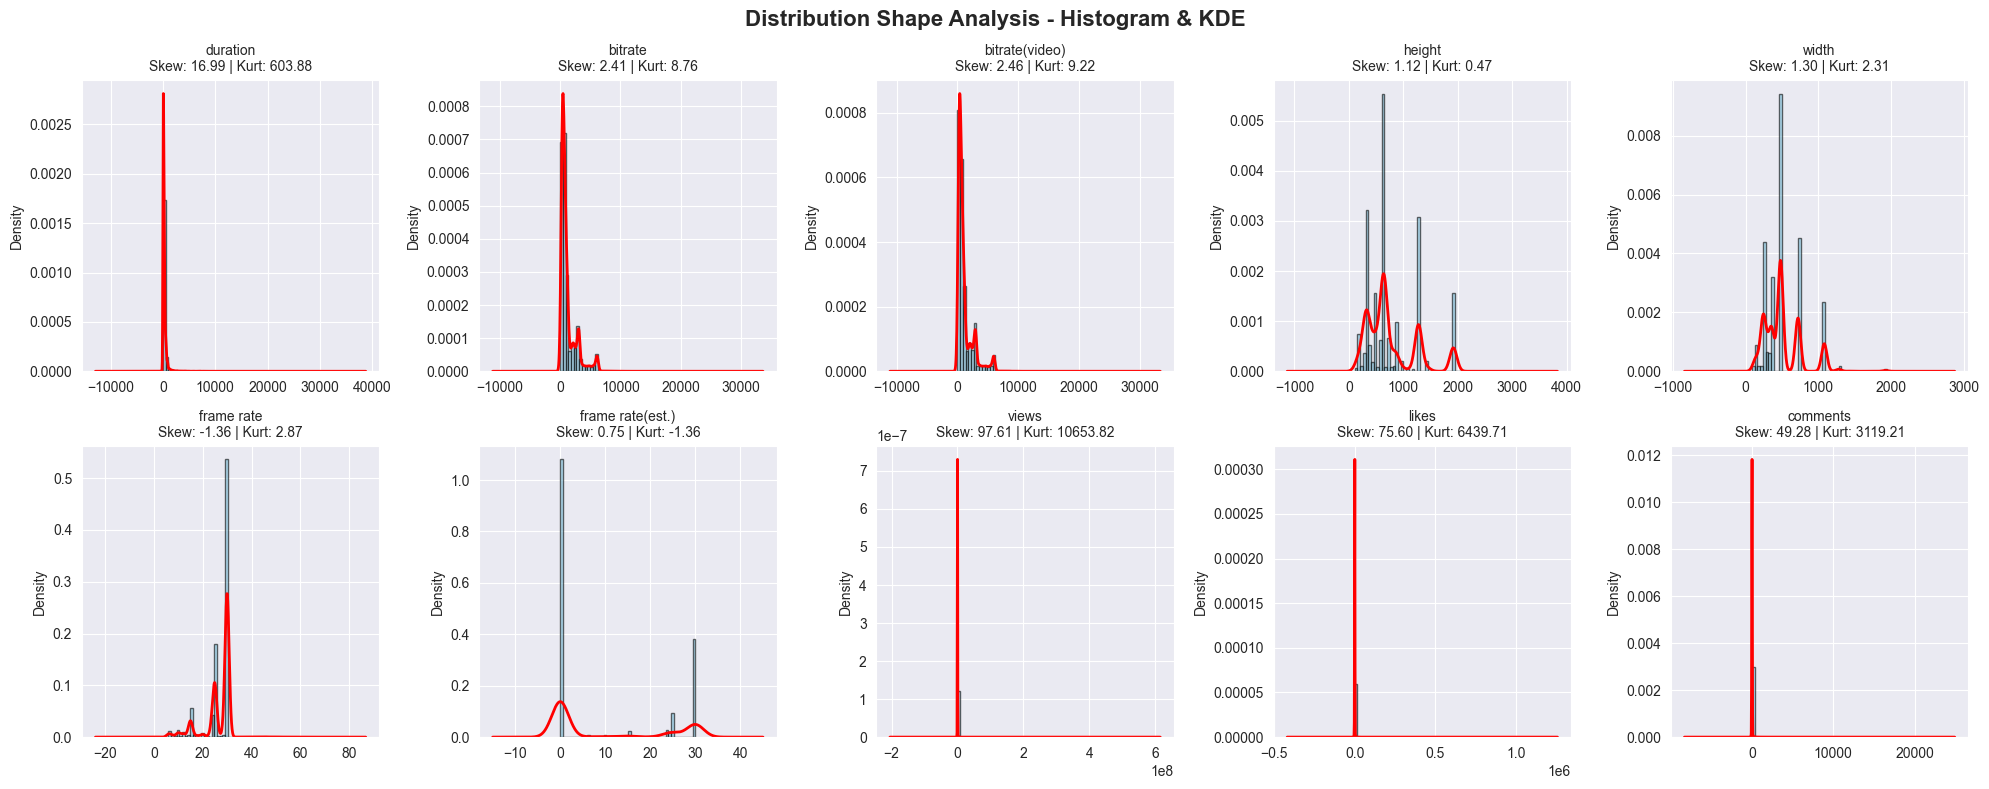

In [4]:
# Visualize Shape Analysis
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Distribution Shape Analysis - Histogram & KDE', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    row = idx // 5
    col_idx = idx % 5

    ax = axes[row, col_idx]

    # Histogram + KDE
    ax.hist(df[col], bins=50, alpha=0.6, color='skyblue', edgecolor='black', density=True)
    df[col].plot(kind='kde', ax=ax, color='red', linewidth=2)

    # Thêm thông tin skewness và kurtosis
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    ax.set_title(f'{col}\nSkew: {skew:.2f} | Kurt: {kurt:.2f}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

- Hầu hết có phân phối **right-skewed** (views, likes, comments có skewness rất cao)
- Có nhiều **outliers** đặc biệt ở views, likes, comments
- Cần xử lý outliers trong phần Distribution Analysis tiếp theo